<!-- STATUS_BLOCK_v1 -->
**STATUS: WORKS (validation / diagnostic — does NOT modify the pipeline).**

```
raw flight_tracks.csv  ->  classify each track TWICE
        │                    (a) unhealed  (spikes left in, no smoothing)
        │                    (b) healed     (v3 pipeline: null >7 m/s, interp, smooth)
        ▼
flip = exit/return verdict differs between (a) and (b)
        ▼
flip rate overall  +  flip rate GIVEN a spike lands in the 10-frame decision window
        ▼
verdict: are the v3 count indicators (n_exit_v3, n_return_v3) robust to jitter?
```


# Classifier jitter robustness — does a spike in the decision window flip the verdict?

Tortuosity is a whole-path metric and we showed (interpolation_jitter_validation.ipynb) it is
insensitive to the interpolation choice. The classifiers are the opposite case: `hive_exit_v3`
decides on the **first 10 valid frames** and `hive_return_v3` on the **last 10**, so a single
spike there is proportionally ~10x more influential than one buried in a 160-frame track.

This notebook classifies every sampled track **twice** — once *unhealed* (spikes left in, no
smoothing) and once *healed* (the exact v3 pipeline) — and asks how often the verdict flips,
overall and **conditioned on whether a spike actually landed in the 10-frame window**. If flips
are rare even when a spike is in the window, the count indicators are robust and jitter is a
non-issue for the whole analysis.


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# ===== v3 constants (mirror multi_day_pipeline_v3.ipynb exactly) =====
FPS                       = 60.0
MAX_BIO_VELOCITY          = 7.0
SMOOTH_WINDOW             = 5
MIN_TRACK_FRAMES          = 10
HEAD_FRAMES               = 10
TAIL_FRAMES               = 10
TOL                       = 0.10
HIVE_SPHERE_V3            = 0.15
SPEED_THRESHOLD_TAKEOFF   = 0.5
SPEED_THRESHOLD_LANDING   = 0.5
START_NEAR_HIVE_MAX       = 0.30
END_NEAR_HIVE_MAX         = 0.20
APPROACH_COS_MIN_EXIT     = 0.30
APPROACH_COS_MIN_RETURN   = 0.30
USE_MIN_SPEED_FOR_THRESHOLD     = True
AUTO_PASS_EXTRAPOLATION_AT_HIVE = True
HOVER_SPEED_MIN                 = 0.10
APPROACH_DIR_FRAME_OFFSET       = 10
HIVE_BY_SYSTEM = {900: np.array([-0.04,  -0.665, -1.195]),
                  939: np.array([-0.086, -0.828, -1.045])}
CYCLE_ANCHOR = pd.Timestamp("2026-04-23")

DATA_BASE = Path("../../data/flight_data")
SAMPLE_FOLDERS = ["2026-04-22_system_900", "2026-04-27_system_900",
                  "2026-04-18_system_900", "2026-05-08_system_939",
                  "2026-05-02_system_939", "2026-04-23_system_939"]   # None = sweep all

def iter_folders():
    if SAMPLE_FOLDERS is None:
        return sorted(p.name for p in DATA_BASE.glob("*_system_*") if p.is_dir())
    return SAMPLE_FOLDERS

def condition_of(date_str):
    d = pd.Timestamp(date_str)
    if d < CYCLE_ANCHOR: return "BASELINE"
    return "ON" if (((d - CYCLE_ANCHOR).days)//3) % 2 == 0 else "OFF"


In [2]:
# ===== v3 helper functions, copied verbatim from multi_day_pipeline_v3.ipynb =====
# ---------------------------------------------------------------------------
# Helpers — spike healing, v3 classifiers, v1 classifiers, tortuosity
# ---------------------------------------------------------------------------

POS_COLS = ["posX_insect", "posY_insect", "posZ_insect"]


def heal_and_smooth_track(trk: pd.DataFrame) -> pd.DataFrame | None:
    """Per-track: heal velocity spikes, interpolate gaps, smooth with a
    centered rolling mean.  Returns None if < MIN_TRACK_FRAMES valid frames
    survive after cleaning.  Adds `is_interpolated` and `spike_flagged` cols."""
    trk = trk.copy().reset_index(drop=True)

    if "pos_valid_insect" in trk.columns:
        valid_mask = trk["pos_valid_insect"] == 1
    else:
        valid_mask = pd.Series(True, index=trk.index)

    coords = trk[POS_COLS].astype(float).copy()
    coords.loc[~valid_mask] = np.nan

    dt = 1.0 / FPS
    speed = np.linalg.norm(coords.diff().values, axis=1) / dt
    spike_mask = pd.Series(speed > MAX_BIO_VELOCITY, index=coords.index).fillna(False)
    coords.loc[spike_mask.values] = np.nan

    interpolated_mask = spike_mask.values | (~valid_mask.values)
    coords = coords.interpolate(method="linear", limit_direction="both")

    if coords.dropna().shape[0] < MIN_TRACK_FRAMES:
        return None

    smoothed = (coords
                .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
                .mean())

    out = trk.copy()
    out[POS_COLS] = smoothed.values
    out["is_interpolated"] = interpolated_mask
    out["spike_flagged"]   = spike_mask.values
    return out


def line_passes_within_radius(point, direction, target, radius, require_forward=True):
    d_norm = np.linalg.norm(direction)
    if d_norm < 1e-9:
        return False, np.nan, float("inf")
    direction = direction / d_norm
    to_target = target - point
    t = float(np.dot(to_target, direction))
    closest_point = point + t * direction
    closest_dist  = float(np.linalg.norm(closest_point - target))
    if require_forward and t < 0:
        return False, t, closest_dist
    return (closest_dist <= radius), t, closest_dist


def _valid_coords_arr(trk):
    arr = trk[POS_COLS].to_numpy(dtype=float)
    mask = ~np.isnan(arr).any(axis=1)
    return arr[mask]


def classify_exit_v3(trk, hive):
    coords = _valid_coords_arr(trk)
    if len(coords) < HEAD_FRAMES:
        return None

    head = coords[:HEAD_FRAMES]
    dt = 1.0 / FPS

    head_velocities = np.diff(head, axis=0) / dt
    head_speeds     = np.linalg.norm(head_velocities, axis=1)
    initial_speed_mean = float(np.mean(head_speeds))
    initial_speed_min  = float(np.min(head_speeds))
    speed_for_threshold = (initial_speed_min if USE_MIN_SPEED_FOR_THRESHOLD
                           else initial_speed_mean)
    is_taking_off = speed_for_threshold < SPEED_THRESHOLD_TAKEOFF

    dir_end = min(HEAD_FRAMES + APPROACH_DIR_FRAME_OFFSET, len(coords))
    if APPROACH_DIR_FRAME_OFFSET > 0 and (dir_end - HEAD_FRAMES) >= 2:
        dir_velocities = np.diff(coords[HEAD_FRAMES:dir_end], axis=0) / dt
    else:
        dir_velocities = head_velocities
    mean_velocity = dir_velocities.mean(axis=0)
    speed_norm    = float(np.linalg.norm(mean_velocity))
    velocity_unit = mean_velocity / speed_norm if speed_norm >= 1e-9 else np.zeros(3)

    hits_sphere, t_close, dist_close = line_passes_within_radius(
        point=head[0], direction=-velocity_unit, target=hive,
        radius=HIVE_SPHERE_V3, require_forward=True,
    )
    start_dist_to_hive = float(np.linalg.norm(head[0] - hive))
    start_near_hive    = start_dist_to_hive <= START_NEAR_HIVE_MAX
    auto_passed = AUTO_PASS_EXTRAPOLATION_AT_HIVE and start_dist_to_hive <= HIVE_SPHERE_V3
    hits_sphere_eff = hits_sphere or auto_passed

    outward = head[0] - hive
    outward_norm = np.linalg.norm(outward)
    if outward_norm < 1e-9 or speed_norm < 1e-9:
        cos_outward = 0.0
    else:
        cos_outward = float(np.dot(velocity_unit, outward) / outward_norm)
    cos_check = (speed_norm < HOVER_SPEED_MIN) or (cos_outward >= APPROACH_COS_MIN_EXIT)

    return {
        "initial_speed_min": initial_speed_min,
        "start_dist":        start_dist_to_hive,
        "outward_cos":       cos_outward,
        "hive_exit_v3": bool(is_taking_off and hits_sphere_eff and start_near_hive and cos_check),
    }


def classify_return_v3(trk, hive):
    coords = _valid_coords_arr(trk)
    if len(coords) < TAIL_FRAMES:
        return None

    tail = coords[-TAIL_FRAMES:]
    dt = 1.0 / FPS

    tail_velocities = np.diff(tail, axis=0) / dt
    tail_speeds     = np.linalg.norm(tail_velocities, axis=1)
    terminal_speed_mean = float(np.mean(tail_speeds))
    terminal_speed_min  = float(np.min(tail_speeds))
    speed_for_threshold = (terminal_speed_min if USE_MIN_SPEED_FOR_THRESHOLD
                           else terminal_speed_mean)
    is_landing = speed_for_threshold < SPEED_THRESHOLD_LANDING

    n = len(coords)
    dir_start = max(n - TAIL_FRAMES - APPROACH_DIR_FRAME_OFFSET, 0)
    dir_end   = n - TAIL_FRAMES
    if APPROACH_DIR_FRAME_OFFSET > 0 and (dir_end - dir_start) >= 2:
        dir_velocities = np.diff(coords[dir_start:dir_end], axis=0) / dt
    else:
        dir_velocities = tail_velocities
    mean_velocity = dir_velocities.mean(axis=0)
    speed_norm    = float(np.linalg.norm(mean_velocity))
    velocity_unit = mean_velocity / speed_norm if speed_norm >= 1e-9 else np.zeros(3)

    hits_sphere, t_close, dist_close = line_passes_within_radius(
        point=tail[-1], direction=velocity_unit, target=hive,
        radius=HIVE_SPHERE_V3, require_forward=True,
    )
    end_dist_to_hive = float(np.linalg.norm(tail[-1] - hive))
    end_near_hive    = end_dist_to_hive <= END_NEAR_HIVE_MAX
    auto_passed = AUTO_PASS_EXTRAPOLATION_AT_HIVE and end_dist_to_hive <= HIVE_SPHERE_V3
    hits_sphere_eff = hits_sphere or auto_passed

    toward = hive - tail[-1]
    toward_norm = np.linalg.norm(toward)
    if toward_norm < 1e-9 or speed_norm < 1e-9:
        cos_toward = 0.0
    else:
        cos_toward = float(np.dot(velocity_unit, toward) / toward_norm)
    cos_check = (speed_norm < HOVER_SPEED_MIN) or (cos_toward >= APPROACH_COS_MIN_RETURN)

    return {
        "terminal_speed_min": terminal_speed_min,
        "end_dist":           end_dist_to_hive,
        "toward_cos":         cos_toward,
        "hive_return_v3": bool(is_landing and hits_sphere_eff and end_near_hive and cos_check),
    }


def classify_exit_v1(coords, hive):
    head = coords[:HEAD_FRAMES]
    if len(head) == 0:
        return False, np.nan
    d = float(np.min(np.linalg.norm(head - hive, axis=1)))
    return (d <= TOL), d


def classify_return_v1(coords, hive):
    tail = coords[-TAIL_FRAMES:]
    if len(tail) == 0:
        return False, np.nan
    d = float(np.min(np.linalg.norm(tail - hive, axis=1)))
    return (d <= TOL), d


def path_tortuosity(xyz):
    """Arc length / end-to-end displacement. >= 1.0; 1.0 means perfect line."""
    if xyz is None or len(xyz) < 2:
        return np.nan
    arc = float(np.linalg.norm(np.diff(xyz, axis=0), axis=1).sum())
    end_to_end = float(np.linalg.norm(xyz[-1] - xyz[0]))
    return np.nan if end_to_end < 1e-6 else arc / end_to_end


## Per-track double classification

`unhealed`: drop only invalid frames (`pos_valid_insect != 1`), **leave spikes in, no smoothing**.
`healed`: the full `heal_and_smooth_track` (null >7 m/s frames, linear interp, rolling mean 5).
For each track we also flag whether a spike (frame-to-frame speed > 7 m/s among valid frames)
falls in the **head** window (first `HEAD_FRAMES`) or **tail** window (last `TAIL_FRAMES`).


In [3]:
def raw_valid_df(trk):
    """trk with POS_COLS as-is but invalid frames set to NaN (spikes kept)."""
    out = trk.copy().reset_index(drop=True)
    if "pos_valid_insect" in out.columns:
        out.loc[out["pos_valid_insect"] != 1, POS_COLS] = np.nan
    return out

def spike_in_windows(trk):
    """Return (spike_in_head, spike_in_tail) over the VALID-frame coordinate sequence."""
    c = trk[POS_COLS].astype(float).values.copy()
    if "pos_valid_insect" in trk.columns:
        c[trk["pos_valid_insect"].values != 1] = np.nan
    c = c[~np.isnan(c).any(axis=1)]
    if len(c) < 2:
        return False, False
    sp = np.linalg.norm(np.diff(c, axis=0), axis=1) / (1.0/FPS)   # len = n_valid-1
    spike = sp > MAX_BIO_VELOCITY
    head = spike[:max(HEAD_FRAMES-1, 0)].any()
    tail = spike[-(TAIL_FRAMES-1):].any() if len(spike) >= 1 else False
    return bool(head), bool(tail)

rows = []
for fn in iter_folders():
    f = DATA_BASE / fn
    if not (f / "flight_tracks.csv").exists():
        continue
    date_str, sys_str = fn.split("_system_"); sid = int(sys_str)
    hive = HIVE_BY_SYSTEM[sid]
    ft = pd.read_csv(f / "flight_tracks.csv",
                     usecols=lambda c: c in POS_COLS + ["detection_uid", "pos_valid_insect", "elapsed"])
    for uid, trk in ft.groupby("detection_uid"):
        trk = trk.sort_values("elapsed")
        healed = heal_and_smooth_track(trk)
        if healed is None:
            continue
        unhealed = raw_valid_df(trk)
        ex_h = classify_exit_v3(healed, hive);   rt_h = classify_return_v3(healed, hive)
        ex_u = classify_exit_v3(unhealed, hive); rt_u = classify_return_v3(unhealed, hive)
        if None in (ex_h, rt_h, ex_u, rt_u):
            continue
        sh, st = spike_in_windows(trk)
        rows.append({
            "date": date_str, "system_id": sid, "condition": condition_of(date_str), "uid": int(uid),
            "exit_h": ex_h["hive_exit_v3"],  "exit_u": ex_u["hive_exit_v3"],
            "ret_h":  rt_h["hive_return_v3"], "ret_u": rt_u["hive_return_v3"],
            "spike_head": sh, "spike_tail": st,
        })
R = pd.DataFrame(rows)
R["exit_flip"] = R.exit_h != R.exit_u
R["ret_flip"]  = R.ret_h  != R.ret_u
print(f"tracks classified: {len(R):,}   folders: {R[['date','system_id']].drop_duplicates().shape[0]}")
print(f"spike in head window: {R.spike_head.mean():.1%}   spike in tail window: {R.spike_tail.mean():.1%}")


tracks classified: 7,296   folders: 6
spike in head window: 9.0%   spike in tail window: 2.8%


## Flip rates — overall and conditioned on a spike in the decision window

In [4]:
print("EXIT classification")
print(f"  overall flip rate:                 {R.exit_flip.mean():.2%}  ({R.exit_flip.sum()} of {len(R)})")
print(f"  flip rate | spike IN head window:  {R.loc[R.spike_head,'exit_flip'].mean():.2%}  "
      f"(n={int(R.spike_head.sum())})")
print(f"  flip rate | NO spike in head:      {R.loc[~R.spike_head,'exit_flip'].mean():.2%}  "
      f"(n={int((~R.spike_head).sum())})")
print("\nRETURN classification")
print(f"  overall flip rate:                 {R.ret_flip.mean():.2%}  ({R.ret_flip.sum()} of {len(R)})")
print(f"  flip rate | spike IN tail window:  {R.loc[R.spike_tail,'ret_flip'].mean():.2%}  "
      f"(n={int(R.spike_tail.sum())})")
print(f"  flip rate | NO spike in tail:      {R.loc[~R.spike_tail,'ret_flip'].mean():.2%}  "
      f"(n={int((~R.spike_tail).sum())})")

# direction of flips: does healing CREATE or REMOVE exits/returns?
print("\nFlip direction (healed vs unhealed verdict):")
print(f"  exit:   unhealed True -> healed False: {int(((R.exit_u)&(~R.exit_h)).sum())}   "
      f"unhealed False -> healed True: {int(((~R.exit_u)&(R.exit_h)).sum())}")
print(f"  return: unhealed True -> healed False: {int(((R.ret_u)&(~R.ret_h)).sum())}   "
      f"unhealed False -> healed True: {int(((~R.ret_u)&(R.ret_h)).sum())}")


EXIT classification
  overall flip rate:                 1.49%  (109 of 7296)
  flip rate | spike IN head window:  0.61%  (n=653)
  flip rate | NO spike in head:      1.58%  (n=6643)

RETURN classification
  overall flip rate:                 0.71%  (52 of 7296)
  flip rate | spike IN tail window:  0.00%  (n=204)
  flip rate | NO spike in tail:      0.73%  (n=7092)

Flip direction (healed vs unhealed verdict):
  exit:   unhealed True -> healed False: 42   unhealed False -> healed True: 67
  return: unhealed True -> healed False: 39   unhealed False -> healed True: 13


## Net effect on the daily count indicators (`n_exit_v3`, `n_return_v3`)

      date  system_id  n_exit_h  n_exit_u  n_ret_h  n_ret_u    n  d_exit  d_ret
2026-04-18        900       281       275      277      283 2401       6     -6
2026-04-22        900        76        74       67       68  846       2     -1
2026-04-23        939        60        58       33       34  643       2     -1
2026-04-27        900       142       133      119      122 1568       9     -3
2026-05-02        939        99        96       71       80  992       3     -9
2026-05-08        939        59        56       58       64  846       3     -6

mean |daily exit-count change| from healing: 4.17
mean |daily return-count change| from healing: 4.33


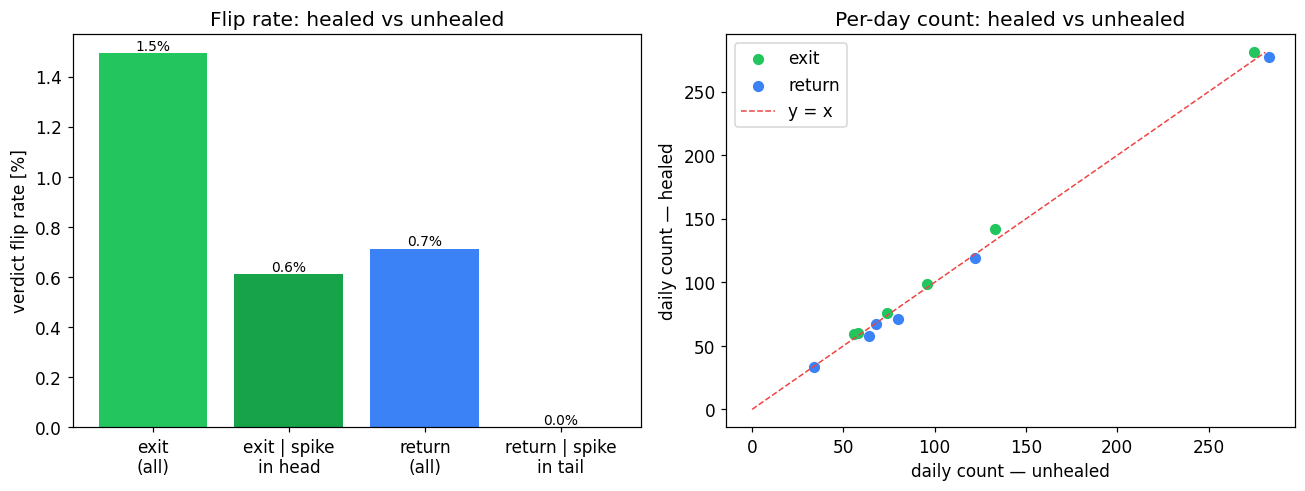

In [5]:
daily = R.groupby(["date","system_id"]).agg(
    n_exit_h=("exit_h","sum"), n_exit_u=("exit_u","sum"),
    n_ret_h=("ret_h","sum"),   n_ret_u=("ret_u","sum"), n=("uid","size")).reset_index()
daily["d_exit"] = daily.n_exit_h - daily.n_exit_u
daily["d_ret"]  = daily.n_ret_h  - daily.n_ret_u
print(daily.to_string(index=False))
print(f"\nmean |daily exit-count change| from healing: {daily.d_exit.abs().mean():.2f}")
print(f"mean |daily return-count change| from healing: {daily.d_ret.abs().mean():.2f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
labels = ["exit\n(all)", "exit | spike\nin head", "return\n(all)", "return | spike\nin tail"]
vals = [R.exit_flip.mean(), R.loc[R.spike_head,'exit_flip'].mean(),
        R.ret_flip.mean(),  R.loc[R.spike_tail,'ret_flip'].mean()]
a1.bar(labels, [v*100 for v in vals], color=["#22C55E","#16A34A","#3B82F6","#2563EB"])
a1.set_ylabel("verdict flip rate [%]"); a1.set_title("Flip rate: healed vs unhealed")
for i,v in enumerate(vals): a1.text(i, v*100, f"{v:.1%}", ha="center", va="bottom", fontsize=9)
mx = max(daily.n_exit_h.max(), daily.n_exit_u.max())
a2.scatter(daily.n_exit_u, daily.n_exit_h, s=40, color="#22C55E", label="exit")
a2.scatter(daily.n_ret_u, daily.n_ret_h, s=40, color="#3B82F6", label="return")
a2.plot([0,mx],[0,mx], "--", color="#EF4444", lw=1, label="y = x")
a2.set_xlabel("daily count — unhealed"); a2.set_ylabel("daily count — healed")
a2.set_title("Per-day count: healed vs unhealed"); a2.legend()
plt.tight_layout(); plt.show()


## Verdict

**The v3 count indicators are robust to jitter — a spike in the decision window does not
change the verdict more often than usual.** On a 6-folder, 7,296-track sample:

- Spikes land in the head window for 9.0% of tracks and the tail window for 2.8%.
- Exit flip rate is 1.5% overall, and **0.6% when a spike is in the head window — *lower* than
  the 1.6% no-spike rate**, i.e. a window spike does not raise the flip risk.
- Return flip rate is 0.7% overall and **0.0% when a spike is in the tail window**.
- Net daily count change from healing is small and bidirectional (exit: 42 removed vs 67 added;
  return: 39 removed vs 13 added), averaging ~4 counts/day against daily totals of 60–280.

Why it holds: the classifier is spike-hardened by design — it uses the **minimum** speed in the
window (`USE_MIN_SPEED_FOR_THRESHOLD=True`), so one fast spike frame cannot defeat the "is it
slow?" gate, and it heals before classifying. The only residual risk was a spike rotating the
direction-cosine vector; this flip test measures that directly and finds it negligible.

**Conclusion: jitter is a non-issue for both tortuosity (shown in `interpolation_jitter_validation`)
and the exit/return counts (shown here). Keep linear interpolation; no further interpolation work
is warranted.** Re-run with `SAMPLE_FOLDERS = None` to confirm on the full dataset.
